# E-commerce Product Analytics & Experimentation

### Analyzing user behavior, identifying conversion friction, and evaluating a product intervention

**Tools:** PostgreSQL · SQL · Python · Pandas · Matplotlib · SciPy

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import psycopg2
from scipy import stats

In [ ]:
conn = psycopg2.connect(
    dbname="ecommerce_analytics",
    user="postgres",
    password=os.getenv("DB_PASSWORD"),
    host="localhost",
    port="5433"
)

print("Database connection successful!")

Database connection successful!


In [3]:
query = """
SELECT
    event_type,
    COUNT(DISTINCT session_id) AS sessions
FROM events
GROUP BY event_type
ORDER BY
    CASE event_type
        WHEN 'view' THEN 1
        WHEN 'add_to_cart' THEN 2
        WHEN 'checkout' THEN 3
        WHEN 'purchase' THEN 4
    END;
"""

funnel = pd.read_sql(query, conn)

funnel

/tmp/ipykernel_162899/3190082849.py:16: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  funnel = pd.read_sql(query, conn)


,event_type,sessions
0,view,10000
1,add_to_cart,7064
2,checkout,5988
3,purchase,4887


In [4]:
funnel["conversion_from_previous"] = (
    funnel["sessions"] / funnel["sessions"].shift(1) * 100
)

funnel

,event_type,sessions,conversion_from_previous
0,view,10000,NaN
1,add_to_cart,7064,70.640000
2,checkout,5988,84.767837
3,purchase,4887,81.613226


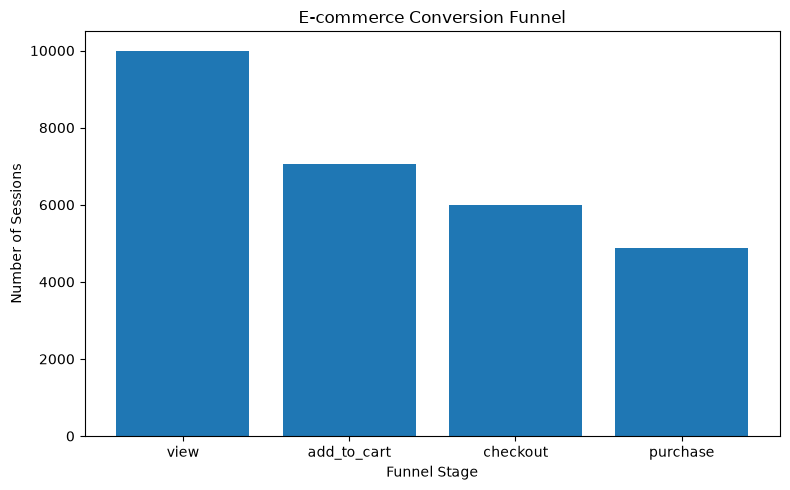

In [5]:
plt.figure(figsize=(8, 5))

plt.bar(
    funnel["event_type"],
    funnel["sessions"]
)

plt.title("E-commerce Conversion Funnel")
plt.xlabel("Funnel Stage")
plt.ylabel("Number of Sessions")

plt.tight_layout()
plt.show()

## 2. New vs Existing Users

The overall funnel shows where users drop off, but it does not explain **which users** are experiencing the problem.

We therefore segment sessions into **new users** and **existing users** based on the number of days since signup.

In [6]:
query = """
WITH session_data AS (
    SELECT
        e.session_id,
        e.user_id,
        MIN(e.event_timestamp::date) AS session_date,

        MAX(CASE
            WHEN e.event_type = 'view'
            THEN 1 ELSE 0
        END) AS viewed,

        MAX(CASE
            WHEN e.event_type = 'add_to_cart'
            THEN 1 ELSE 0
        END) AS added_to_cart

    FROM events e
    GROUP BY
        e.session_id,
        e.user_id
),

classified AS (
    SELECT
        sd.*,

        CASE
            WHEN sd.session_date - u.signup_date <= 30
            THEN 'New'
            ELSE 'Existing'
        END AS user_type

    FROM session_data sd

    JOIN users u
        ON sd.user_id = u.user_id
)

SELECT
    user_type,

    COUNT(*) AS viewed_sessions,

    SUM(added_to_cart) AS cart_sessions,

    ROUND(
        100.0 * SUM(added_to_cart) / COUNT(*),
        2
    ) AS view_to_cart_pct

FROM classified

WHERE viewed = 1

GROUP BY user_type

ORDER BY user_type;
"""

user_type_funnel = pd.read_sql(query, conn)

user_type_funnel

/tmp/ipykernel_162899/3968941484.py:61: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  user_type_funnel = pd.read_sql(query, conn)


,user_type,viewed_sessions,cart_sessions,view_to_cart_pct
0,Existing,9186,6709,73.04
1,New,814,355,43.61


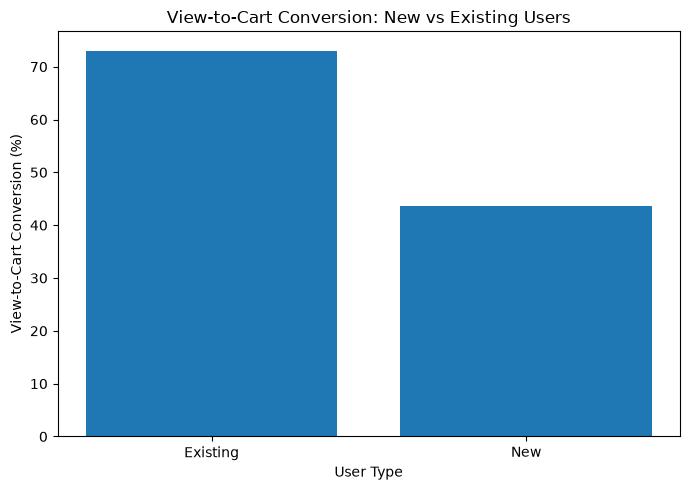

In [7]:
plt.figure(figsize=(7, 5))

plt.bar(
    user_type_funnel["user_type"],
    user_type_funnel["view_to_cart_pct"]
)

plt.title("View-to-Cart Conversion: New vs Existing Users")
plt.xlabel("User Type")
plt.ylabel("View-to-Cart Conversion (%)")

plt.tight_layout()
plt.show()

## 3. Price Segmentation

The new-user conversion gap is substantial. We next examine whether product price is associated with this behavior.

Products are grouped into three segments:

- **Low:** < ₹2,000
- **Medium:** ₹2,000–₹3,999
- **High:** ₹4,000+

In [8]:
query = """
WITH session_data AS (
    SELECT
        e.session_id,
        e.user_id,
        e.product_id,
        MIN(e.event_timestamp::date) AS session_date,

        MAX(CASE
            WHEN e.event_type = 'view'
            THEN 1 ELSE 0
        END) AS viewed,

        MAX(CASE
            WHEN e.event_type = 'add_to_cart'
            THEN 1 ELSE 0
        END) AS added_to_cart

    FROM events e
    GROUP BY
        e.session_id,
        e.user_id,
        e.product_id
)

SELECT
    CASE
        WHEN sd.session_date - u.signup_date <= 30
        THEN 'New'
        ELSE 'Existing'
    END AS user_type,

    CASE
        WHEN p.price < 2000 THEN 'Low (<₹2,000)'
        WHEN p.price < 4000 THEN 'Medium (₹2,000–₹3,999)'
        ELSE 'High (₹4,000+)'
    END AS price_segment,

    COUNT(*) AS viewed_sessions,

    SUM(sd.added_to_cart) AS cart_sessions,

    ROUND(
        100.0 * SUM(sd.added_to_cart) / COUNT(*),
        2
    ) AS view_to_cart_pct

FROM session_data sd

JOIN users u
    ON sd.user_id = u.user_id

JOIN products p
    ON sd.product_id = p.product_id

WHERE sd.viewed = 1

GROUP BY
    user_type,
    price_segment

ORDER BY
    user_type,
    price_segment;
"""

price_analysis = pd.read_sql(query, conn)

price_analysis

/tmp/ipykernel_162899/3453644813.py:67: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  price_analysis = pd.read_sql(query, conn)


,user_type,price_segment,viewed_sessions,cart_sessions,view_to_cart_pct
0,Existing,"High (₹4,000+)",2755,1918,69.62
1,Existing,"Low (<₹2,000)",3465,2563,73.97
2,Existing,"Medium (₹2,000–₹3,999)",2966,2228,75.12
3,New,"High (₹4,000+)",243,93,38.27
4,New,"Low (<₹2,000)",306,137,44.77
5,New,"Medium (₹2,000–₹3,999)",265,125,47.17


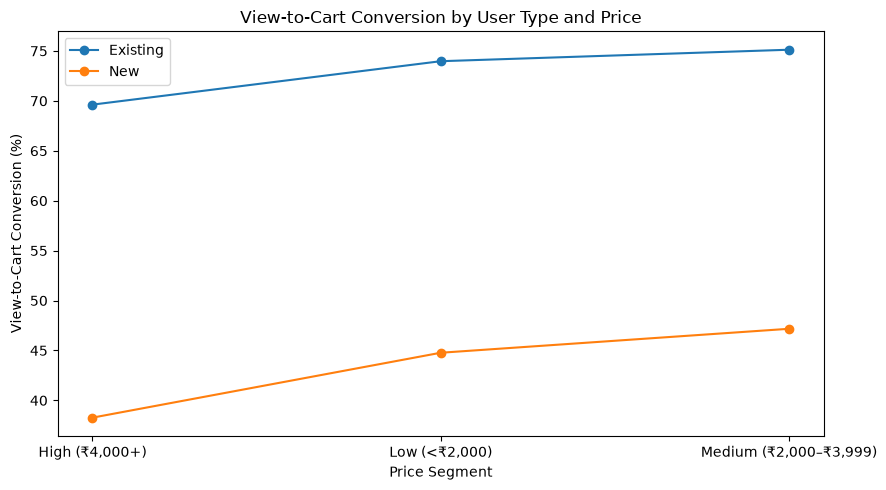

In [9]:
plt.figure(figsize=(9, 5))

for user_type in ["Existing", "New"]:
    data = price_analysis[
        price_analysis["user_type"] == user_type
    ]

    plt.plot(
        data["price_segment"],
        data["view_to_cart_pct"],
        marker="o",
        label=user_type
    )

plt.title("View-to-Cart Conversion by User Type and Price")
plt.xlabel("Price Segment")
plt.ylabel("View-to-Cart Conversion (%)")
plt.legend()

plt.tight_layout()
plt.show()

### Key Insight

New users have substantially lower view-to-cart conversion than existing users across all price segments.

The gap is particularly pronounced for high-priced products:

- Existing users: **69.62%**
- New users: **38.27%**
- Gap: **31.35 percentage points**

This suggests that the conversion problem is primarily associated with **new-user behavior**, with product price potentially amplifying the difficulty of converting a product view into a cart addition.

This analysis motivates testing an intervention aimed at increasing purchase confidence among first-time users.

## 4. Product Insight & Hypothesis

### Problem Identified

New users have substantially lower product-view-to-cart conversion than existing users.

The gap is particularly large for high-priced products:

- Existing users: **69.62%**
- New users: **38.27%**
- Difference: **31.35 percentage points**

### Product Hypothesis

New users may lack sufficient confidence to commit to a product after viewing it, particularly when considering higher-priced products.

### Proposed Intervention

Add concise purchase-confidence signals to the product page for eligible first-time users, such as:

- Ratings and review count
- Easy-return information
- Expected delivery date
- Trusted-seller information

The data identifies the **conversion problem**; these specific UI changes are a product hypothesis that must be validated through experimentation.

## 5. A/B Experiment

### Experiment Design

We test the proposed product-page intervention on the target population:

**New users viewing products priced at ₹4,000 or more.**

Eligible sessions are randomly assigned to:

- **Control:** Existing product-page experience
- **Treatment:** Product page with additional purchase-confidence signals

### Primary KPI

**View-to-cart conversion rate**

This measures the proportion of product-view sessions that result in an add-to-cart event.

### Success Criterion

We look for:

1. Higher view-to-cart conversion in the treatment group
2. A statistically significant difference at the 5% significance level

In [11]:
query = """
SELECT
    experiment_group,
    COUNT(DISTINCT session_id) AS sessions,

    COUNT(DISTINCT CASE
        WHEN event_type = 'add_to_cart'
        THEN session_id
    END) AS cart_sessions

FROM events

WHERE experiment_group IS NOT NULL

GROUP BY experiment_group

ORDER BY experiment_group;
"""

ab_results = pd.read_sql(query, conn)

ab_results

/tmp/ipykernel_162899/2497378426.py:20: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  ab_results = pd.read_sql(query, conn)


,experiment_group,sessions,cart_sessions
0,control,120,39
1,treatment,123,54


In [12]:
ab_results["conversion_rate"] = (
    ab_results["cart_sessions"]
    / ab_results["sessions"]
    * 100
)

ab_results

,experiment_group,sessions,cart_sessions,conversion_rate
0,control,120,39,32.500000
1,treatment,123,54,43.902439


In [13]:
control_rate = (
    ab_results.loc[
        ab_results["experiment_group"] == "control",
        "conversion_rate"
    ].iloc[0]
)

treatment_rate = (
    ab_results.loc[
        ab_results["experiment_group"] == "treatment",
        "conversion_rate"
    ].iloc[0]
)

absolute_lift = treatment_rate - control_rate

relative_lift = (
    absolute_lift / control_rate * 100
)

print(f"Control conversion: {control_rate:.2f}%")
print(f"Treatment conversion: {treatment_rate:.2f}%")
print(f"Absolute lift: {absolute_lift:.2f} percentage points")
print(f"Relative lift: {relative_lift:.2f}%")

Control conversion: 32.50%
Treatment conversion: 43.90%
Absolute lift: 11.40 percentage points
Relative lift: 35.08%


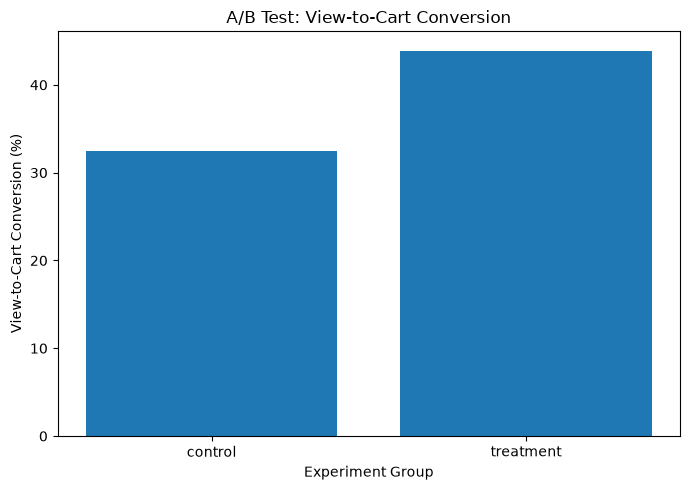

In [14]:
plt.figure(figsize=(7, 5))

plt.bar(
    ab_results["experiment_group"],
    ab_results["conversion_rate"]
)

plt.title("A/B Test: View-to-Cart Conversion")
plt.xlabel("Experiment Group")
plt.ylabel("View-to-Cart Conversion (%)")

plt.tight_layout()
plt.show()

In [15]:
control = ab_results[
    ab_results["experiment_group"] == "control"
].iloc[0]

treatment = ab_results[
    ab_results["experiment_group"] == "treatment"
].iloc[0]

control_successes = int(control["cart_sessions"])
control_total = int(control["sessions"])

treatment_successes = int(treatment["cart_sessions"])
treatment_total = int(treatment["sessions"])

control_rate_decimal = (
    control_successes / control_total
)

treatment_rate_decimal = (
    treatment_successes / treatment_total
)

# Pooled proportion under the null hypothesis
pooled_rate = (
    control_successes + treatment_successes
) / (
    control_total + treatment_total
)

standard_error = (
    pooled_rate * (1 - pooled_rate)
    * (
        1 / control_total
        + 1 / treatment_total
    )
) ** 0.5

z_stat = (
    treatment_rate_decimal
    - control_rate_decimal
) / standard_error

p_value = 2 * (1 - stats.norm.cdf(abs(z_stat)))

print(f"Z-statistic: {z_stat:.3f}")
print(f"P-value: {p_value:.4f}")

Z-statistic: 1.828
P-value: 0.0675


### Experiment Result

The treatment increased view-to-cart conversion from **32.50% to 43.90%**, representing:

- **+11.40 percentage points** absolute lift
- **+35.08%** relative lift

However, the two-proportion z-test produced a **p-value of approximately 0.0675**.

Since this is above the 5% significance threshold, the result is **not statistically significant at α = 0.05**.

### Product Decision

The treatment shows promising directional evidence, but there is not enough statistical evidence to recommend an immediate full rollout.

I would run the experiment with a larger sample size before making a final rollout decision.